In [2]:
# ==========================================
# CONNEXION MYSQL
# ==========================================

import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Connexion à la base
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="visiteur",
    database="classicmodels"  # ou ta base
)

cursor = conn.cursor()

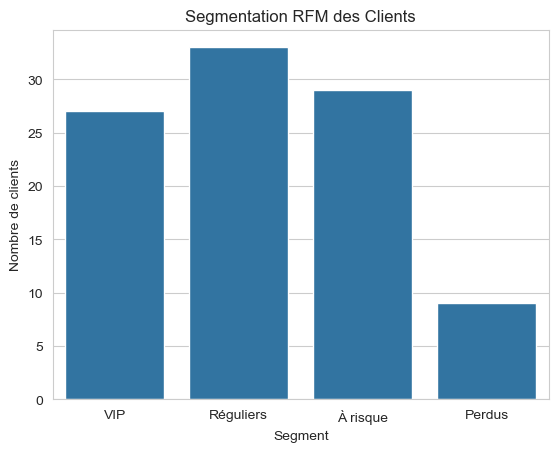

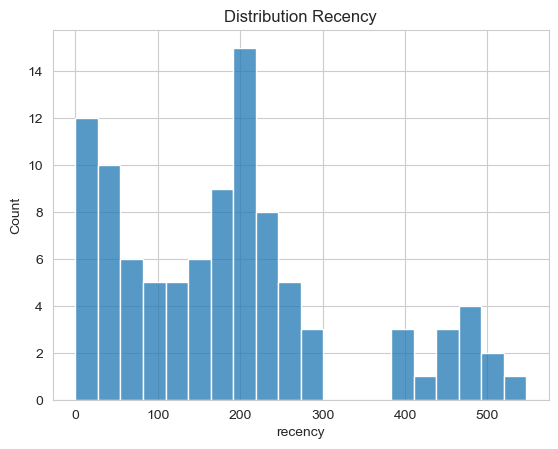

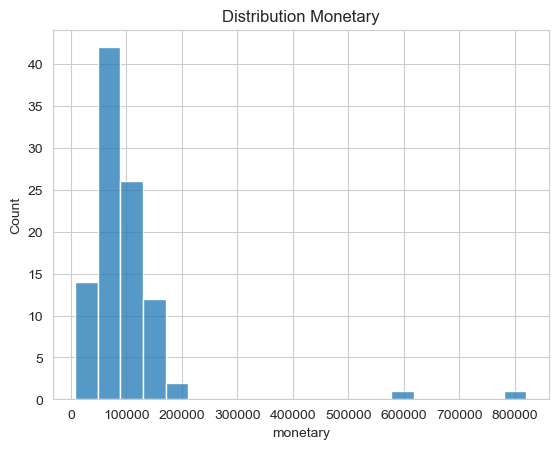

              recency  frequency       monetary  nb_clients
segment                                                    
Perdus     372.888889   1.888889   47042.282222           9
Réguliers  145.727273   3.121212   85300.315455          33
VIP         60.259259   5.222222  169384.122593          27
À risque   280.000000   2.241379   61811.322414          29


In [20]:
# =====================================================
# 1) SCORING RFM STABLE
# =====================================================

# RANK pour éviter les valeurs identiques problématiques
df_rfm['recency_rank'] = df_rfm['recency'].rank(method='first')
df_rfm['frequency_rank'] = df_rfm['frequency'].rank(method='first')
df_rfm['monetary_rank'] = df_rfm['monetary'].rank(method='first')

# Création des scores avec qcut
df_rfm['R_score'] = pd.qcut(
    df_rfm['recency_rank'],
    q=4,
    labels=[4,3,2,1]
)

df_rfm['F_score'] = pd.qcut(
    df_rfm['frequency_rank'],
    q=4,
    labels=[1,2,3,4]
)

df_rfm['M_score'] = pd.qcut(
    df_rfm['monetary_rank'],
    q=4,
    labels=[1,2,3,4]
)

# Conversion en int
df_rfm[['R_score','F_score','M_score']] = df_rfm[['R_score','F_score','M_score']].astype(int)

# Score total
df_rfm['RFM_score'] = df_rfm[['R_score','F_score','M_score']].sum(axis=1)
# -----------------------------------------------------
# Visualisations
# -----------------------------------------------------

sns.set_style("whitegrid")

# 1. Répartition des segments
plt.figure()
sns.countplot(x='segment', data=df_rfm, order=['VIP','Réguliers','À risque','Perdus'])
plt.title("Segmentation RFM des Clients")
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")
plt.show()

# 2. Distribution Recency / Frequency / Monetary
plt.figure()
sns.histplot(df_rfm['recency'], bins=20)
plt.title("Distribution Recency")
plt.show()

plt.figure()
sns.histplot(df_rfm['monetary'], bins=20)
plt.title("Distribution Monetary")
plt.show()

# -----------------------------------------------------
# Résumé statistique par segment
# -----------------------------------------------------

segment_analysis = df_rfm.groupby('segment').agg({
    'recency':'mean',
    'frequency':'mean',
    'monetary':'mean',
    'customerNumber':'count'
}).rename(columns={'customerNumber':'nb_clients'})

print(segment_analysis)

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\4142750580.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_corr = pd.read_sql(query_corr, conn)


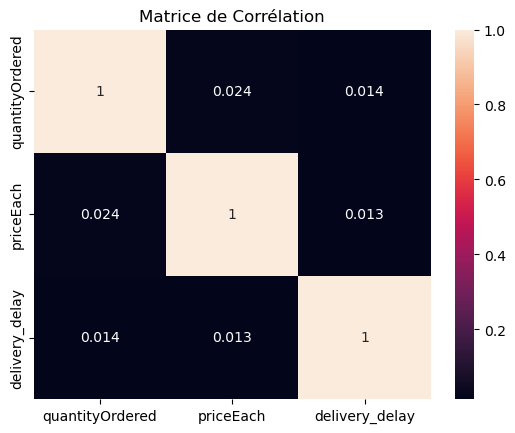

In [19]:
#2) Analyse de correlation
#Extraction
query_corr = """
SELECT 
    od.quantityOrdered,
    od.priceEach,
    DATEDIFF(o.shippedDate, o.orderDate) AS delivery_delay
FROM orderdetails od
JOIN orders o ON od.orderNumber = o.orderNumber
WHERE o.shippedDate IS NOT NULL
"""

df_corr = pd.read_sql(query_corr, conn)
#Matrice correlation
corr_matrix = df_corr.corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Matrice de Corrélation")
plt.show()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\2632564353.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_time = pd.read_sql(query_time, conn)
C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\2632564353.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_time.resample('M').sum()


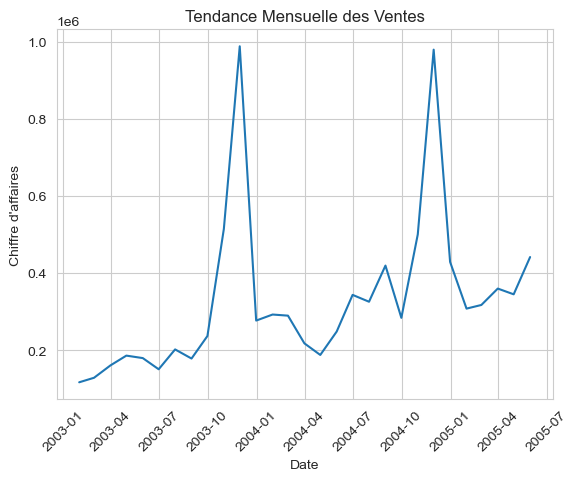

Moyenne des ventes par mois :
month
11    983658.565000
10    507285.035000
12    352780.710000
8     298792.100000
5     289745.263333
7     263751.925000
9     260248.825000
6     246920.755000
3     245973.453333
2     245032.883333
4     239414.993333
1     238938.333333
Name: sales, dtype: float64


C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\2632564353.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales = df_time.resample('Q').sum()


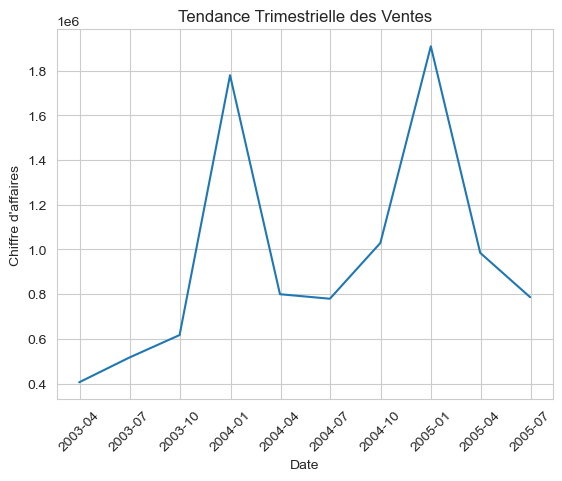

Moyenne des ventes par trimestre :
quarter
4    1.843724e+06
3    8.227928e+05
1    7.299447e+05
2    6.937741e+05
Name: sales, dtype: float64


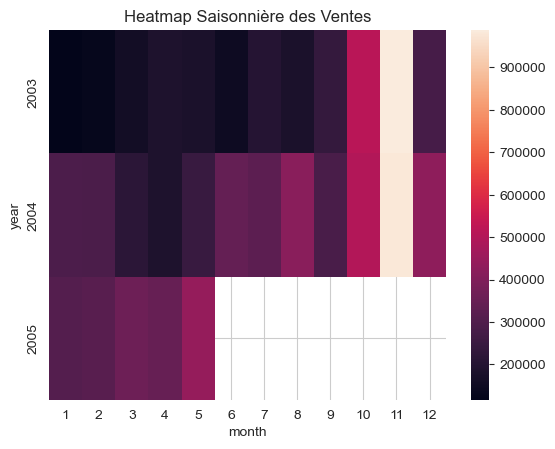

In [21]:
# =====================================================
# 3) ANALYSE TEMPORELLE DES VENTES
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

query_time = """
SELECT 
    o.orderDate,
    SUM(od.quantityOrdered * od.priceEach) AS sales
FROM orders o
JOIN orderdetails od ON o.orderNumber = od.orderNumber
GROUP BY o.orderDate
ORDER BY o.orderDate
"""

df_time = pd.read_sql(query_time, conn)

# Conversion date
df_time['orderDate'] = pd.to_datetime(df_time['orderDate'])
df_time.set_index('orderDate', inplace=True)
# Agrégation mensuelle
monthly_sales = df_time.resample('M').sum()

plt.figure()
plt.plot(monthly_sales.index, monthly_sales['sales'])
plt.title("Tendance Mensuelle des Ventes")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.show()
monthly_sales['month'] = monthly_sales.index.month

avg_by_month = monthly_sales.groupby('month')['sales'].mean()

print("Moyenne des ventes par mois :")
print(avg_by_month.sort_values(ascending=False))


# Agrégation trimestrielle
quarterly_sales = df_time.resample('Q').sum()

plt.figure()
plt.plot(quarterly_sales.index, quarterly_sales['sales'])
plt.title("Tendance Trimestrielle des Ventes")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.show()

quarterly_sales['quarter'] = quarterly_sales.index.quarter

avg_by_quarter = quarterly_sales.groupby('quarter')['sales'].mean()

print("Moyenne des ventes par trimestre :")
print(avg_by_quarter.sort_values(ascending=False))




# Création tableau année / mois
df_time['year'] = df_time.index.year
df_time['month'] = df_time.index.month

pivot = df_time.pivot_table(
    values='sales',
    index='year',
    columns='month',
    aggfunc='sum'
)

plt.figure()
sns.heatmap(pivot)
plt.title("Heatmap Saisonnière des Ventes")
plt.show()



C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\2885624907.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_avg = pd.read_sql(query_avg, conn)


Panier moyen : 29460.71
Panier médian : 30273.76
Panier maximum : 67392.85


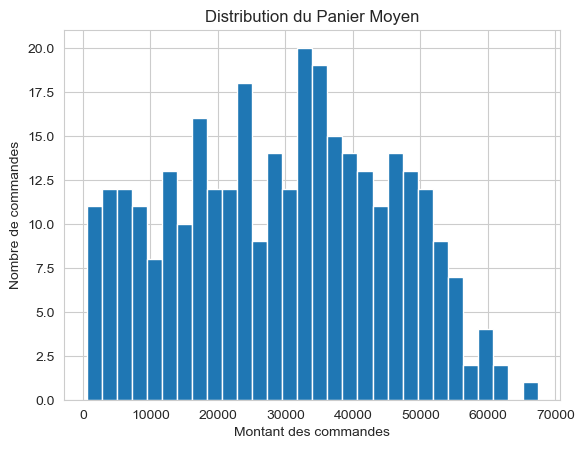

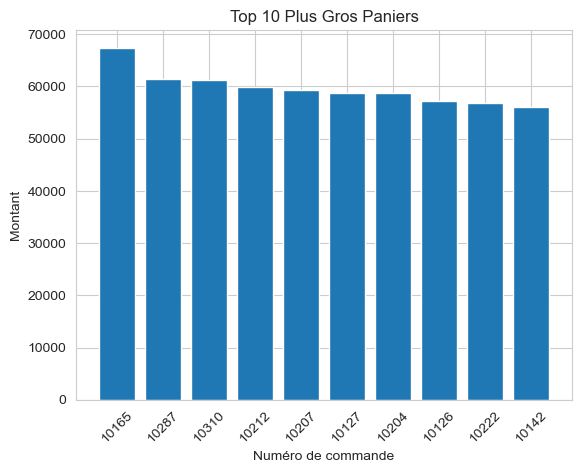

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\2885624907.py:59: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql(query_products, conn)



Top 10 Produits Souvent Achetés Ensemble :
       Product_1  Product_2  Count
10015   S50_1341  S700_1691     28
2982    S18_2319   S18_3232     27
3852    S18_2957   S18_3136     27
10789  S700_2047   S72_1253     27
7376    S24_2841   S24_3420     27
8499    S24_3949  S700_4002     27
249     S10_2016   S18_2625     26
11553  S700_3962   S72_3212     26
9904    S32_4485   S50_4713     26
3111    S18_2325   S24_1937     26


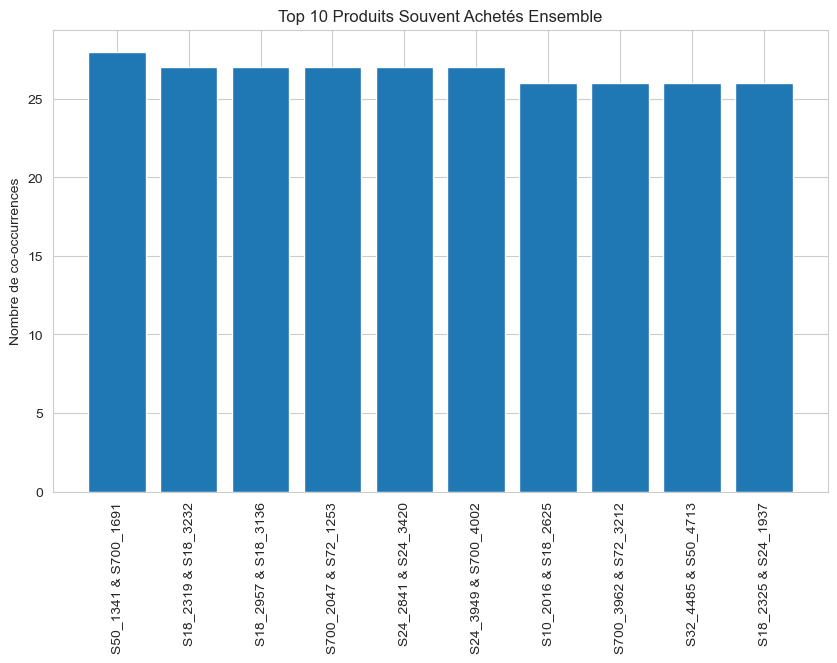

In [30]:
# =====================================================
# 4) ANALYSE DU PANIER MOYEN ET PRODUITS SOUVENT ACHETÉS ENSEMBLE
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARTIE A : PANIER MOYEN
# -----------------------------

query_avg = """
SELECT 
    o.orderNumber,
    SUM(od.quantityOrdered * od.priceEach) AS order_total
FROM orders o
JOIN orderdetails od ON o.orderNumber = od.orderNumber
GROUP BY o.orderNumber
ORDER BY o.orderNumber
"""
df_avg = pd.read_sql(query_avg, conn)

average_basket = df_avg['order_total'].mean()
median_basket = df_avg['order_total'].median()
max_basket = df_avg['order_total'].max()

print("Panier moyen :", round(average_basket,2))
print("Panier médian :", round(median_basket,2))
print("Panier maximum :", round(max_basket,2))

# Distribution
plt.figure()
plt.hist(df_avg['order_total'], bins=30)
plt.title("Distribution du Panier Moyen")
plt.xlabel("Montant des commandes")
plt.ylabel("Nombre de commandes")
plt.show()

# Top 10 plus gros paniers
top_orders = df_avg.sort_values(by='order_total', ascending=False).head(10)
plt.figure()
plt.bar(top_orders['orderNumber'].astype(str), top_orders['order_total'])
plt.xticks(rotation=45)
plt.title("Top 10 Plus Gros Paniers")
plt.xlabel("Numéro de commande")
plt.ylabel("Montant")
plt.show()


# -----------------------------
# PARTIE B : PRODUITS ACHETÉS ENSEMBLE
# -----------------------------

query_products = """
SELECT orderNumber, productCode
FROM orderdetails
"""
df_products = pd.read_sql(query_products, conn)

# Matrice binaire (1 = produit présent)
basket = df_products.groupby(['orderNumber','productCode']).size().unstack(fill_value=0)

# Conversion en binaire
basket = (basket > 0).astype(int)

# Matrice de co-occurrence
co_occurrence = basket.T.dot(basket)

# Suppression auto-co-occurrence
np.fill_diagonal(co_occurrence.values, 0)

# S'assurer que les noms de colonnes sont uniques
co_occurrence = co_occurrence.copy()
co_occurrence.columns = [str(col) for col in co_occurrence.columns]
co_occurrence.index = [str(idx) for idx in co_occurrence.index]

# Transformer en DataFrame long sans conflit
pairs = co_occurrence.stack().reset_index()
pairs.columns = ['Product_1', 'Product_2', 'Count']

# Supprimer doublons miroir (A-B et B-A)
pairs = pairs[pairs['Product_1'] < pairs['Product_2']]

# Trier et garder Top 10
top_pairs = pairs.sort_values(by='Count', ascending=False).head(10)

print("\nTop 10 Produits Souvent Achetés Ensemble :")
print(top_pairs)

# Visualisation Top 10
plt.figure(figsize=(10,6))
plt.bar(
    top_pairs['Product_1'] + " & " + top_pairs['Product_2'],
    top_pairs['Count']
)
plt.xticks(rotation=90)
plt.title("Top 10 Produits Souvent Achetés Ensemble")
plt.ylabel("Nombre de co-occurrences")
plt.show()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\4190786221.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emp = pd.read_sql(query_emp, conn)
C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\4190786221.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employeeName', y='chiffre_affaires', data=df_emp, palette='Blues_d')


    employeeNumber      employeeName  nb_clients  chiffre_affaires  \
0             1370  Gerard Hernandez           7        1258577.81   
1             1165   Leslie Jennings           6        1081530.54   
2             1401   Pamela Castillo          10         868220.55   
3             1501        Larry Bott           8         732096.79   
4             1504       Barry Jones           9         704853.91   
5             1323     George Vanauf           8         669377.05   
6             1612       Peter Marsh           5         584593.76   
7             1337       Loui Bondur           6         569485.75   
8             1611       Andy Fixter           5         562582.59   
9             1216   Steve Patterson           6         505875.42   
10            1286    Foon Yue Tseng           6         488212.67   
11            1621        Mami Nishi           5         457110.07   
12            1702     Martin Gerard           5         387477.47   
13            1188  

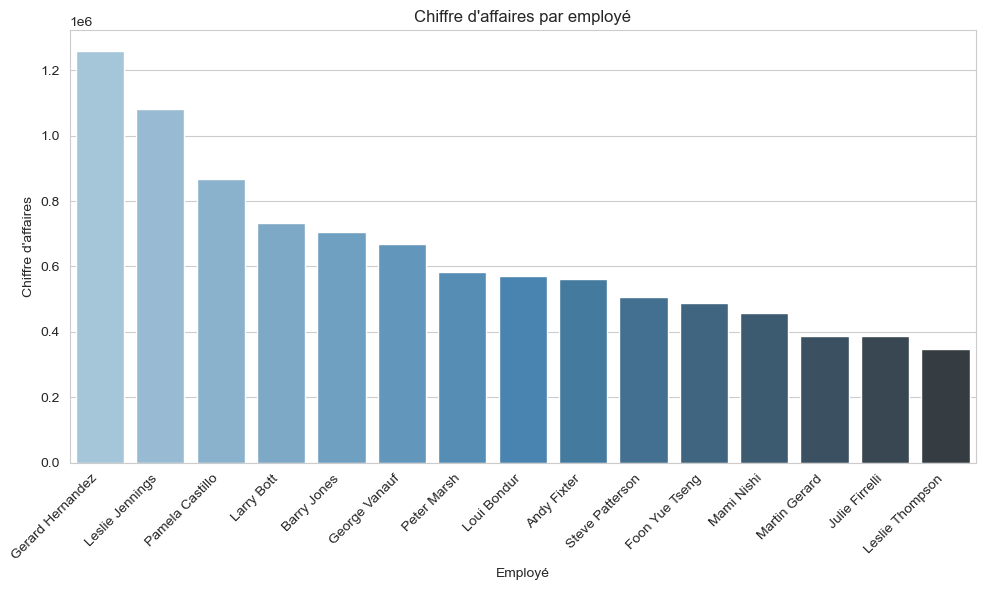

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\4190786221.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employeeName', y='nb_clients', data=df_emp, palette='Greens_d')


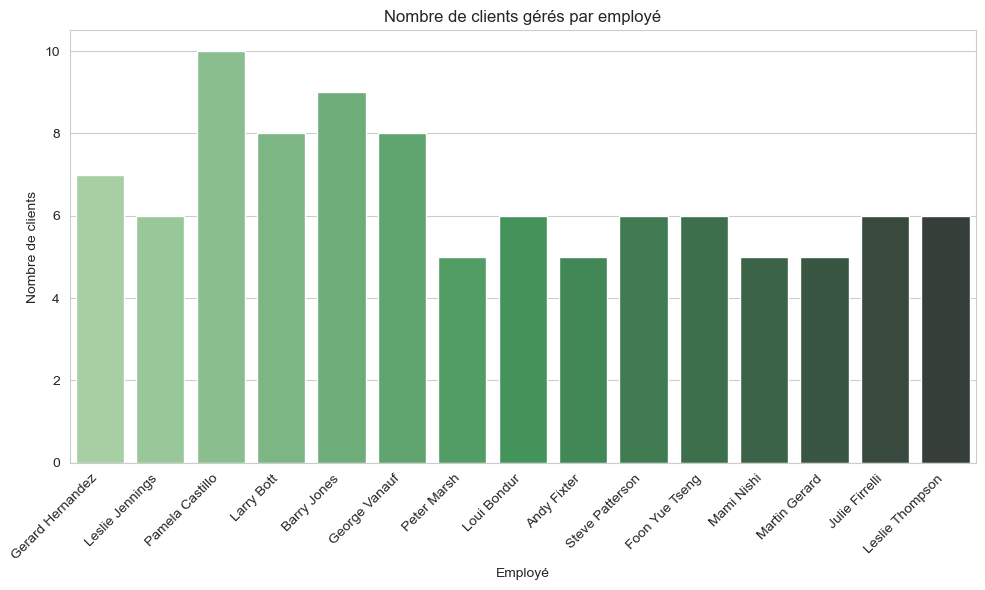

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_18500\4190786221.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employeeName', y='panier_moyen', data=df_emp, palette='Oranges_d')


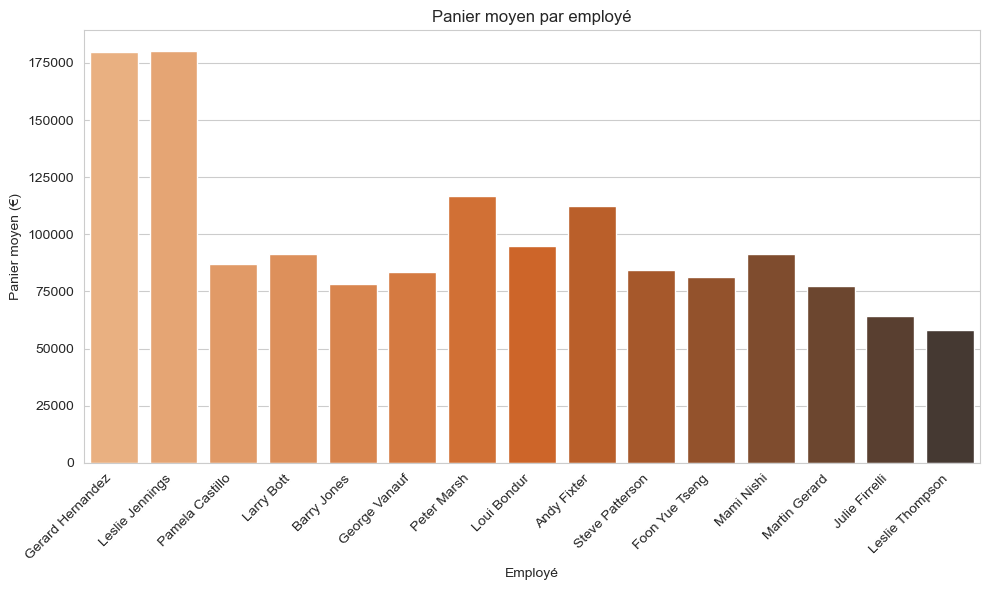

In [31]:
# =====================================================
# 5) PERFORMANCE PAR EMPLOYÉ
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# Extraction des données
# -----------------------------------------------------
query_emp = """
SELECT 
    e.employeeNumber,
    CONCAT(e.firstName,' ',e.lastName) AS employeeName,
    COUNT(DISTINCT c.customerNumber) AS nb_clients,
    SUM(od.quantityOrdered * od.priceEach) AS chiffre_affaires
FROM employees e
JOIN customers c ON e.employeeNumber = c.salesRepEmployeeNumber
JOIN orders o ON c.customerNumber = o.customerNumber
JOIN orderdetails od ON o.orderNumber = od.orderNumber
GROUP BY e.employeeNumber, e.firstName, e.lastName
ORDER BY chiffre_affaires DESC
"""

df_emp = pd.read_sql(query_emp, conn)

# -----------------------------------------------------
# Calcul du panier moyen par employé
# -----------------------------------------------------
df_emp['panier_moyen'] = df_emp['chiffre_affaires'] / df_emp['nb_clients']

# Arrondir pour lisibilité
df_emp['chiffre_affaires'] = df_emp['chiffre_affaires'].round(2)
df_emp['panier_moyen'] = df_emp['panier_moyen'].round(2)

print(df_emp)

# -----------------------------------------------------
# Visualisation 1 : Chiffre d'affaires par employé
# -----------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x='employeeName', y='chiffre_affaires', data=df_emp, palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title("Chiffre d'affaires par employé")
plt.ylabel("Chiffre d'affaires")
plt.xlabel("Employé")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# Visualisation 2 : Nombre de clients gérés par employé
# -----------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x='employeeName', y='nb_clients', data=df_emp, palette='Greens_d')
plt.xticks(rotation=45, ha='right')
plt.title("Nombre de clients gérés par employé")
plt.ylabel("Nombre de clients")
plt.xlabel("Employé")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# Visualisation 3 : Panier moyen par employé
# -----------------------------------------------------
plt.figure(figsize=(10,6))
sns.barplot(x='employeeName', y='panier_moyen', data=df_emp, palette='Oranges_d')
plt.xticks(rotation=45, ha='right')
plt.title("Panier moyen par employé")
plt.ylabel("Panier moyen (€)")
plt.xlabel("Employé")
plt.tight_layout()
plt.show()